In [58]:
from sklearn.datasets import make_regression 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [59]:
X,y=make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

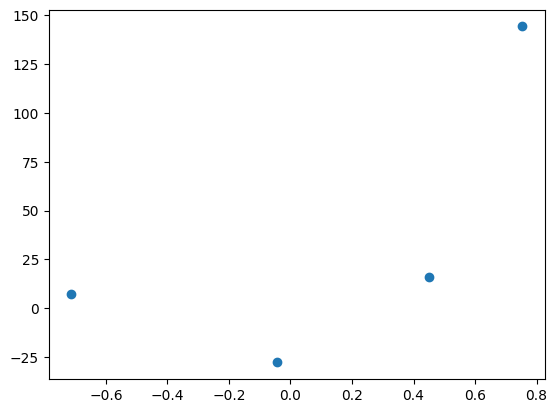

In [60]:
plt.scatter(X,y)

### Line by OLS

In [61]:
from sklearn.linear_model import LinearRegression

In [62]:
reg=LinearRegression()

In [63]:
reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
reg.coef_

array([78.35063668])

#### our target

In [65]:
reg.intercept_ # our target to achieve it

np.float64(26.15963284313262)

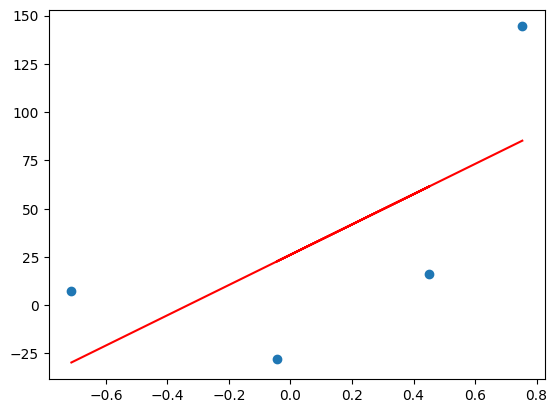

In [66]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red') 
# this is the line achieved by OLS 

### By Gradient Descent 

In [67]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 100

y_pred=((78.35*X)+100).reshape(4)

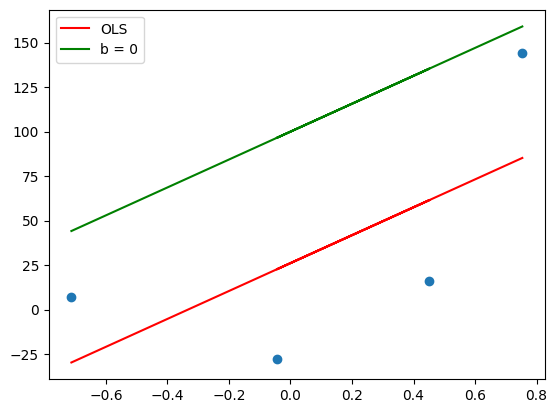

In [68]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')

plt.plot(X,y_pred,color='green',label='b = 0')

plt.legend()
plt.show()

#### 1st iteration

In [69]:
m=78.35
b_old=100

slope= -2*np.sum(y - m*X.ravel() - b_old)
slope

np.float64(590.7223659179078)

In [70]:
# we keep learning rate as 0.1
lr=0.1
step_size= lr*slope
step_size

np.float64(59.072236591790784)

In [71]:
b_new=b_old - step_size
b_new # b increased as slope was negative

np.float64(40.927763408209216)

In [72]:
y_pred_1=((78.35*X) + b_new).reshape(4)
y_pred_1

array([-14.88804496,  76.32726015,  37.44094722,  99.98535918])

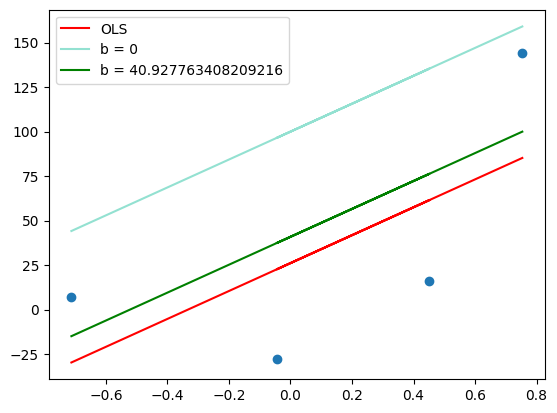

In [73]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')

plt.plot(X,y_pred,color="#93E1D1",label='b = 0')

plt.plot(X,y_pred_1,color='green', label='b = {}'.format(b_new)) # we reached almost 

plt.legend()
plt.show()

#### 2nd Iteration 

In [74]:
slope_1=-2*np.sum(y - m*X.ravel() - b_new)
slope_1

np.float64(118.14447318358157)

In [75]:
step_size_1=lr*slope_1
step_size_1

np.float64(11.814447318358157)

In [76]:
b_new_1= b_new - step_size_1
b_new_1

np.float64(29.11331608985106)

In [77]:
y_pred_2= (m*X + b_new_1).reshape(4)
y_pred_2

array([-26.70249228,  64.51281283,  25.6264999 ,  88.17091186])

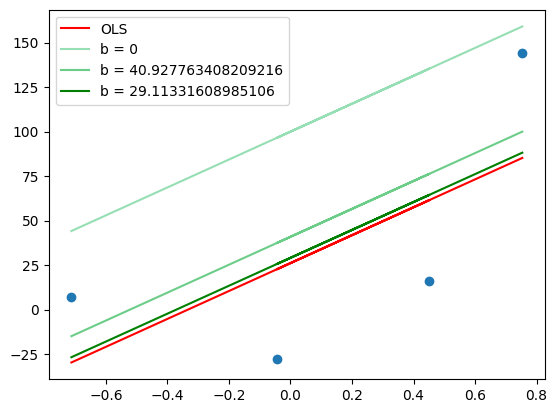

In [81]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')

plt.plot(X,y_pred,color="#96DEB3",label='b = 0')

plt.plot(X,y_pred_1,color="#6CCD89", label='b = {}'.format(b_new)) 

plt.plot(X,y_pred_2,color="green" ,label='b = {}'.format(b_new_1)) # we reached almost 

plt.legend()
plt.show()

#### 3rd Iteration 

In [82]:
slope_2=-2* np.sum(y-m*X.ravel() -b_new_1)
slope_2

np.float64(23.62889463671634)

In [83]:
step_size_2=lr*slope_2
step_size_2

np.float64(2.362889463671634)

##### we got b as what we want 

In [ ]:
b_new_2= b_new_1 - step_size_2
b_new_2 # we got what we want

np.float64(26.750426626179426)

In [86]:
y_pred_3=((m * X) + b_new_2 ).reshape(4)
y_pred_3

array([-29.06538175,  62.14992337,  23.26361044,  85.80802239])

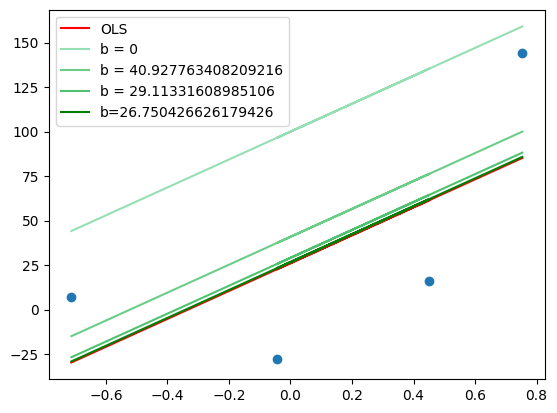

In [89]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')

plt.plot(X,y_pred,color="#96DEB3",label='b = 0')

plt.plot(X,y_pred_1,color="#6CCD89", label='b = {}'.format(b_new)) 

plt.plot(X,y_pred_2,color="#50C172" ,label='b = {}'.format(b_new_1)) 
plt.plot(X,y_pred_3,color='green',label='b={}'.format(b_new_2)) # we reached

plt.legend()
plt.show()



### Doing thats all in one loop 

26.2778487334451


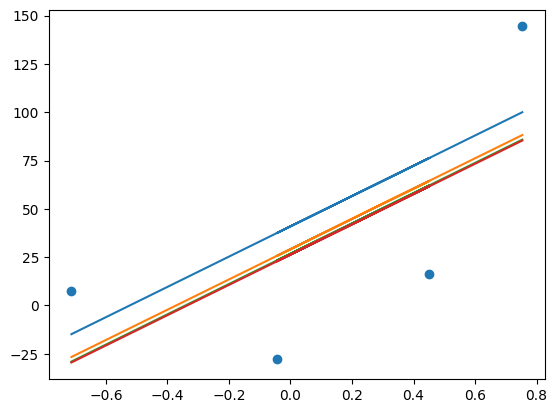

In [99]:
m=78.35
b=100
lr=0.1
epochs=4
for i in range(epochs):
    slope=-2*np.sum(y-m*X.ravel() - b)
    step_size=lr*slope
    b=b-step_size

    y_pred=m*X + b

    plt.plot(X,y_pred)


plt.scatter(X,y)    
print(b)

26.129525360899255


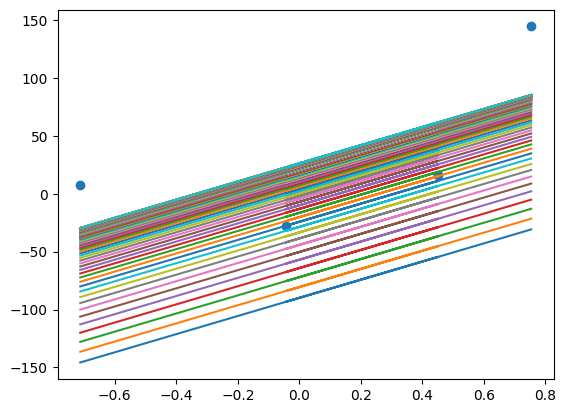

In [ ]:
m=78.35
b=-100
lr=0.01 # more you decrease this value more steps you will take
epochs=100
for i in range(epochs):
    slope=-2*np.sum(y-m*X.ravel() - b)
    step_size=lr*slope
    b=b-step_size

    y_pred=m*X + b

    plt.plot(X,y_pred)


plt.scatter(X,y)   
print(b)  # we exactly reached 


In [ ]:
git add .
git commit  -m "Gradient Descent, finding b in loop "
git push origin main